For demo only.

In [1]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
import os
import json
import pandas as pd

In [2]:
data_path = "./data.xml"; assert os.path.exists(data_path), "File does not exist: {}".format(data_path)
date_path = "./dates.json"; assert os.path.exists(date_path), "File does not exist: {}".format(date_path)

In [3]:
root = ET.parse(data_path).getroot()
dates = json.load(open(date_path, "r"))

sleep_data = [r for r in root.findall("Record")]
print("Total number of records: {}".format(len(sleep_data)))
print("Total days of data: {}".format(len(dates)))

Total number of records: 2070
Total days of data: 66


In [4]:
def feature_extraction(dates, data):
    """
    Extracts the length of each stage of the sleep, as well as the start time and weekday, which are relevant to sleeping routines.
    This function adapts batch computation, which would be way faster than iterative approach.
    """
    raw_df = pd.DataFrame([r.attrib for r in data])
    
    raw_df["startDate"] = pd.to_datetime(raw_df["startDate"], format="%Y-%m-%d %H:%M:%S %z")
    raw_df["endDate"] = pd.to_datetime(raw_df["endDate"], format="%Y-%m-%d %H:%M:%S %z")
    raw_df["duration"] = (raw_df["endDate"] - raw_df["startDate"]).dt.total_seconds() / 60.0
    
    rows = []
    weekday_map = {"Mon": 0, "Tue": 1, "Wed": 2, "Thu" :3, "Fri": 4, "Sat": 5, "Sun": 6}

    for weekday, indices in dates:
        session_slice = raw_df.iloc[indices]
        print(f"start hour is {session_slice['startDate'].min()} for weekday {weekday}")
        core = session_slice[session_slice["value"] == "HKCategoryValueSleepAnalysisAsleepCore"]["duration"].sum()
        deep = session_slice[session_slice["value"] == "HKCategoryValueSleepAnalysisAsleepDeep"]["duration"].sum()
        rem = session_slice[session_slice["value"] == "HKCategoryValueSleepAnalysisAsleepREM"]["duration"].sum()
        awake = session_slice[session_slice["value"] == "HKCategoryValueSleepAnalysisAwake"]["duration"].sum()
        unspecified = session_slice[session_slice["value"] == "HKCategoryValueSleepAnalysisAsleepUnspecified"]["duration"].sum()
        
        start_hour = session_slice["startDate"].min().hour + session_slice["startDate"].min().minute / 60.0
        # The start hour is in 24 hours. In this case, there's huge risk that sleeping starting at noon and sleeping at early night will be clustered together.
        # To mitigate this issue, we can use sine transformation to capture the cyclical nature of time.
        start_sin = np.sin(2 * np.pi * start_hour / 24)
        
        rows.append([start_sin, core, deep, rem, awake, unspecified, weekday_map[weekday]])
    df = pd.DataFrame(rows, columns=["start_sin", "CORE", "DEEP", "REM", "AWAKE", "UNSPECIFIED", "weekday"])
    return df

def train_kmeans(df, n_clusters=5):
    df = df.dropna().copy()
    df = df.replace([np.inf, -np.inf], np.nan).dropna()
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df)
    
    model = KMeans(n_clusters=n_clusters)
    df["cluster"] = model.fit_predict(X_scaled)
    return df, model, scaler

In [5]:
df = feature_extraction(dates, sleep_data)

start hour is 2026-01-24 02:13:44+08:00 for weekday Fri
start hour is 2026-01-25 04:14:44+08:00 for weekday Sat
start hour is 2026-01-26 03:50:46+08:00 for weekday Sun
start hour is 2026-01-26 23:11:11+08:00 for weekday Mon
start hour is 2026-01-28 03:09:51+08:00 for weekday Tue
start hour is 2026-01-29 01:55:01+08:00 for weekday Wed
start hour is 2026-01-30 03:56:48+08:00 for weekday Thu
start hour is 2026-01-31 01:51:45+08:00 for weekday Fri
start hour is 2026-02-01 04:15:13+08:00 for weekday Sat
start hour is 2026-02-02 00:06:24+08:00 for weekday Sun
start hour is 2026-02-03 02:56:13+08:00 for weekday Mon
start hour is 2026-02-04 03:04:44+08:00 for weekday Tue
start hour is 2026-02-05 02:07:43+08:00 for weekday Wed
start hour is 2026-02-06 05:13:47+08:00 for weekday Thu
start hour is 2026-02-07 04:51:06+08:00 for weekday Fri
start hour is 2026-02-08 05:51:21+08:00 for weekday Sat
start hour is 2026-02-09 01:51:57+08:00 for weekday Sun
start hour is 2026-02-10 02:21:21+08:00 for week

In [6]:
# Provisional cluster number
N_CLUSTERS = 3

final_df, model, scaler = train_kmeans(df, n_clusters=N_CLUSTERS)
print(final_df.groupby('cluster').mean())

         start_sin        CORE       DEEP         REM      AWAKE  UNSPECIFIED  \
cluster                                                                         
0         0.166478  314.308333  88.289167  139.248333  19.841667     3.567500   
1         0.726225  240.373643  74.786822  106.345349   7.886822     0.000000   
2         0.522319   59.111111  24.777778   26.288889   5.533333   128.927778   

          weekday  
cluster            
0        3.200000  
1        2.976744  
2        2.666667  


In [7]:
centroids = model.cluster_centers_
centroids_unscaled = scaler.inverse_transform(centroids)

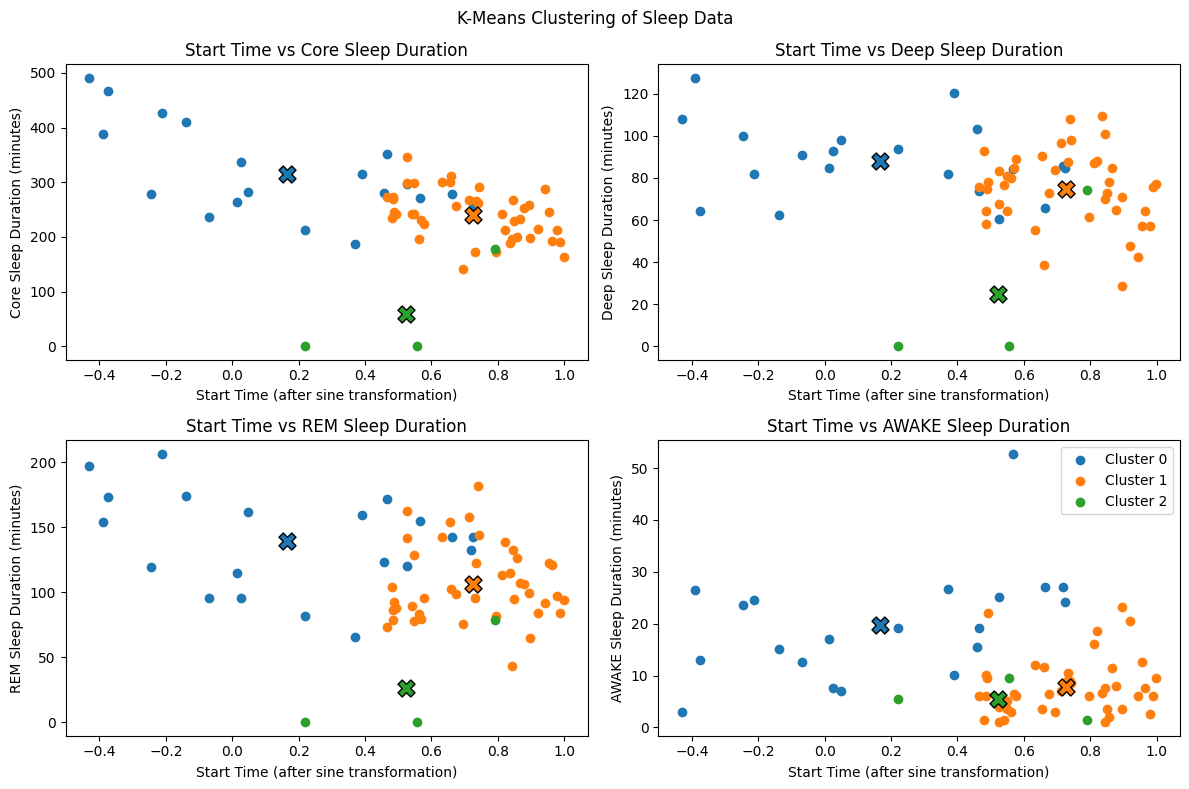

In [8]:
fig=plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
for cluster in range(N_CLUSTERS):
    cluster_data = final_df[final_df['cluster'] == cluster]
    plt.scatter(cluster_data['start_sin'], cluster_data['CORE'], label=f'Cluster {cluster}', marker='o', color=plt.cm.tab10(cluster))
    plt.scatter(centroids_unscaled[cluster][0], centroids_unscaled[cluster][1], marker='X', s=150, edgecolor='black')
plt.xlabel('Start Time (after sine transformation)')
plt.ylabel('Core Sleep Duration (minutes)')
plt.title('Start Time vs Core Sleep Duration')

plt.subplot(2, 2, 2)
for cluster in range(N_CLUSTERS):
    cluster_data = final_df[final_df['cluster'] == cluster]
    plt.scatter(cluster_data['start_sin'], cluster_data['DEEP'], label=f'Cluster {cluster}', marker='o', color=plt.cm.tab10(cluster))
    plt.scatter(centroids_unscaled[cluster][0], centroids_unscaled[cluster][2], marker='X', s=150, edgecolor='black')
plt.xlabel('Start Time (after sine transformation)')
plt.ylabel('Deep Sleep Duration (minutes)')
plt.title('Start Time vs Deep Sleep Duration')

plt.subplot(2, 2, 3)
for cluster in range(N_CLUSTERS):
    cluster_data = final_df[final_df['cluster'] == cluster]
    plt.scatter(cluster_data['start_sin'], cluster_data['REM'], label=f'Cluster {cluster}', marker='o', color=plt.cm.tab10(cluster))
    plt.scatter(centroids_unscaled[cluster][0], centroids_unscaled[cluster][3], marker='X', s=150, edgecolor='black')
plt.xlabel('Start Time (after sine transformation)')
plt.ylabel('REM Sleep Duration (minutes)')
plt.title('Start Time vs REM Sleep Duration')

plt.subplot(2, 2, 4)
for cluster in range(N_CLUSTERS):
    cluster_data = final_df[final_df['cluster'] == cluster]
    plt.scatter(cluster_data['start_sin'], cluster_data['AWAKE'], label=f'Cluster {cluster}', marker='o', color=plt.cm.tab10(cluster))
    plt.scatter(centroids_unscaled[cluster][0], centroids_unscaled[cluster][4], marker='X', s=150, edgecolor='black')
plt.xlabel('Start Time (after sine transformation)')
plt.ylabel('AWAKE Sleep Duration (minutes)')
plt.title('Start Time vs AWAKE Sleep Duration')

plt.suptitle('K-Means Clustering of Sleep Data')
plt.legend()
plt.tight_layout()
plt.show()